# Analysis — Trading Activity and Price Discovery

This notebook loads the trade-level CSVs produced by `pull_data.ipynb`, restricts each
market to an event-anchored time window, and produces the two figures used in the
project:

1. **`trading_activity_final.png`** — normalized trading activity (trades per 15-min bin)
   around each market's information event.
2. **`price_trajectory.png`** — volume-weighted implied probability over time, showing
   when each market reached certainty.

**Information-event anchors (the moment the outcome becomes known):**
- *Indiana (sports):* the final whistle of the CFP championship, 11:16 PM ET Jan 19, 2026.
- *Warsh (politics):* Trump's official Truth Social announcement, 6:48 AM ET Jan 30, 2026.

A Bloomberg report (9:17 PM ET Jan 29) and the game's kickoff (7:30 PM ET Jan 19) are
marked as secondary reference points.

## 1. Setup, load, and clean

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = os.path.join("..", "data")

# Load the two YES-resolving markets analyzed in the project
indiana = pd.read_csv(os.path.join(DATA_DIR, "indiana_championship_trades.csv"))
warsh   = pd.read_csv(os.path.join(DATA_DIR, "warsh_fed_chair_trades.csv"))

# Kalshi returns prices/sizes as strings; force numeric and parse timestamps
for df in (indiana, warsh):
    df["yes_price_dollars"] = pd.to_numeric(df["yes_price_dollars"])
    df["count_fp"]          = pd.to_numeric(df["count_fp"])
    df["created_time"]      = pd.to_datetime(df["created_time"])

print(f"Indiana: {len(indiana):,} trades")
print(f"Warsh:   {len(warsh):,} trades")

Indiana: 134,549 trades
Warsh:   71,969 trades


## 2. Event anchors and time windows

Each market is re-centered so that *t = 0* is its information event. All trades are
expressed in hours relative to that event, and the analysis is restricted to a window
of −16 to +5 hours around it.

In [9]:
# Verified information-event anchors (UTC)
indiana_event = pd.Timestamp("2026-01-20 04:16:00", tz="UTC")  # final whistle (~11:16 PM ET Jan 19)
warsh_event   = pd.Timestamp("2026-01-30 11:48:00", tz="UTC")  # Truth Social post (6:48 AM ET Jan 30)

# Secondary reference points
kickoff        = pd.Timestamp("2026-01-20 00:30:00", tz="UTC")  # 7:30 PM ET Jan 19
bloomberg_leak = pd.Timestamp("2026-01-30 02:17:00", tz="UTC")  # 9:17 PM ET Jan 29

# Position of the reference points on each market's event-relative axis
hours_event_to_kickoff = (kickoff - indiana_event).total_seconds() / 3600
hours_event_to_leak    = (bloomberg_leak - warsh_event).total_seconds() / 3600

# Hours relative to each market's event
indiana["hours_from_event"] = (indiana["created_time"] - indiana_event).dt.total_seconds() / 3600
warsh["hours_from_event"]   = (warsh["created_time"] - warsh_event).dt.total_seconds() / 3600

# Restrict to the analysis window
window_min, window_max = -16, 5
indiana_window = indiana[(indiana["hours_from_event"] >= window_min) & (indiana["hours_from_event"] <= window_max)].copy()
warsh_window   = warsh[(warsh["hours_from_event"] >= window_min) & (warsh["hours_from_event"] <= window_max)].copy()

print(f"Indiana trades in window: {len(indiana_window):,}")
print(f"Warsh trades in window:   {len(warsh_window):,}")

Indiana trades in window: 70,287
Warsh trades in window:   7,952


## 3. Figure 1 — Trading activity around the information event

Trades are binned into 15-minute intervals and normalized to each market's own peak,
so the comparison is about the *shape* of activity rather than absolute volume.

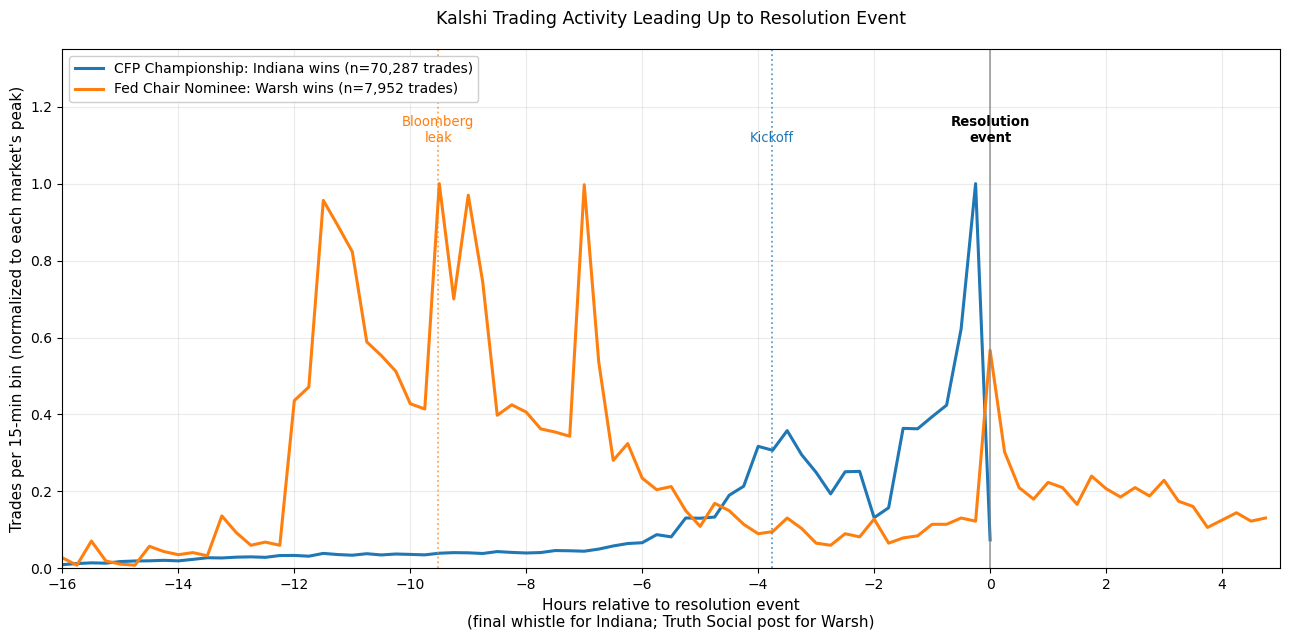

Indiana activity peak: -0.25 h from final whistle
Warsh activity peak:   -9.50 h from announcement


In [10]:
def bin_activity(df, bin_size_min=15):
    df = df.copy()
    df["bin"] = (df["hours_from_event"] * 60 // bin_size_min) * bin_size_min / 60
    return df.groupby("bin").size()

indiana_binned = bin_activity(indiana_window, 15)
warsh_binned   = bin_activity(warsh_window, 15)

fig, ax = plt.subplots(figsize=(13, 6.5))

ax.plot(indiana_binned.index, indiana_binned.values / indiana_binned.max(),
        label=f"CFP Championship: Indiana wins (n={len(indiana_window):,} trades)",
        linewidth=2.2, color="#1f77b4")
ax.plot(warsh_binned.index, warsh_binned.values / warsh_binned.max(),
        label=f"Fed Chair Nominee: Warsh wins (n={len(warsh_window):,} trades)",
        linewidth=2.2, color="#ff7f0e")

# Resolution event at t=0
ax.axvline(x=0, color="gray", linestyle="-", alpha=0.7, linewidth=1.3)
ax.text(0, 1.10, "Resolution\nevent", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

# Bloomberg leak (Warsh reference)
ax.axvline(x=hours_event_to_leak, color="#ff7f0e", linestyle=":", alpha=0.7, linewidth=1.3)
ax.text(hours_event_to_leak, 1.10, "Bloomberg\nleak", ha="center", va="bottom", fontsize=9.5, color="#ff7f0e")

# Kickoff (Indiana reference)
ax.axvline(x=hours_event_to_kickoff, color="#1f77b4", linestyle=":", alpha=0.7, linewidth=1.3)
ax.text(hours_event_to_kickoff, 1.10, "Kickoff", ha="center", va="bottom", fontsize=9.5, color="#1f77b4")

ax.set_xlabel("Hours relative to resolution event\n(final whistle for Indiana; Truth Social post for Warsh)", fontsize=11)
ax.set_ylabel("Trades per 15-min bin (normalized to each market's peak)", fontsize=11)
ax.set_title("Kalshi Trading Activity Leading Up to Resolution Event", fontsize=12.5, pad=18)
ax.legend(loc="upper left", fontsize=10, framealpha=0.95)
ax.grid(alpha=0.25)
ax.set_ylim(0, 1.35)
ax.set_xlim(window_min, window_max)
ax.set_xticks(range(window_min, window_max + 1, 2))

plt.tight_layout()
plt.savefig(os.path.join("..", "output", "trading_activity_final.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Indiana activity peak: {indiana_binned.idxmax():.2f} h from final whistle")
print(f"Warsh activity peak:   {warsh_binned.idxmax():.2f} h from announcement")

## 4. Figure 2 — Implied probability over time

For each 10-minute bin, the volume-weighted average YES price (VWAP) gives the market's
implied probability of the outcome. This shows *when* each market converged on certainty.

/var/folders/rs/xc6_jn1n71dgczpq6783q7v00000gn/T/ipykernel_53172/2731402388.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("bin").apply(
/var/folders/rs/xc6_jn1n71dgczpq6783q7v00000gn/T/ipykernel_53172/2731402388.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("bin").apply(


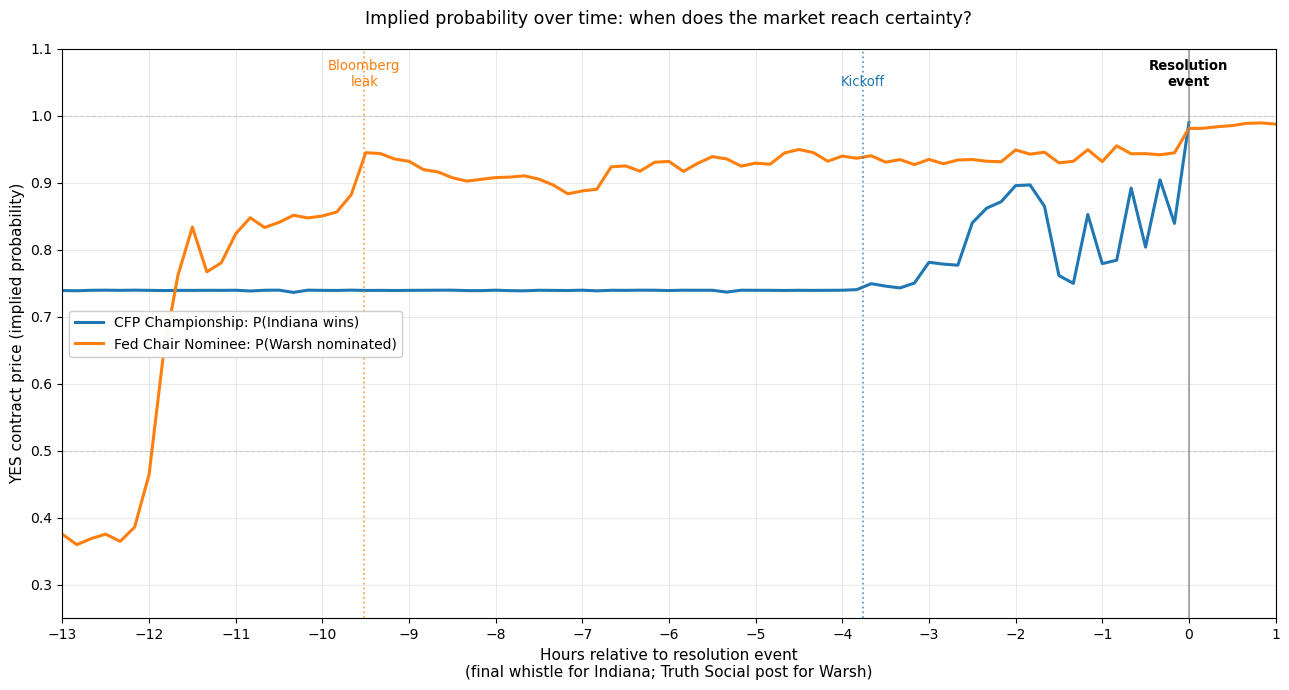

In [11]:
def vwap_per_bin(df, bin_size_min=10):
    df = df.copy()
    df["bin"] = (df["hours_from_event"] * 60 // bin_size_min) * bin_size_min / 60
    return df.groupby("bin").apply(
        lambda g: (g["yes_price_dollars"] * g["count_fp"]).sum() / g["count_fp"].sum()
    )

indiana_vwap = vwap_per_bin(indiana_window, 10)
warsh_vwap   = vwap_per_bin(warsh_window, 10)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(indiana_vwap.index, indiana_vwap.values,
        label="CFP Championship: P(Indiana wins)", linewidth=2.2, color="#1f77b4")
ax.plot(warsh_vwap.index, warsh_vwap.values,
        label="Fed Chair Nominee: P(Warsh nominated)", linewidth=2.2, color="#ff7f0e")

ax.axvline(x=0, color="gray", linestyle="-", alpha=0.7, linewidth=1.3)
ax.text(0, 1.04, "Resolution\nevent", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

ax.axvline(x=hours_event_to_leak, color="#ff7f0e", linestyle=":", alpha=0.7, linewidth=1.3)
ax.text(hours_event_to_leak, 1.04, "Bloomberg\nleak", ha="center", va="bottom", fontsize=9.5, color="#ff7f0e")

ax.axvline(x=hours_event_to_kickoff, color="#1f77b4", linestyle=":", alpha=0.7, linewidth=1.3)
ax.text(hours_event_to_kickoff, 1.04, "Kickoff", ha="center", va="bottom", fontsize=9.5, color="#1f77b4")

ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.3, linewidth=0.8)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3, linewidth=0.8)

ax.set_xlabel("Hours relative to resolution event\n(final whistle for Indiana; Truth Social post for Warsh)", fontsize=11)
ax.set_ylabel("YES contract price (implied probability)", fontsize=11)
ax.set_title("Implied probability over time: when does the market reach certainty?", fontsize=12.5, pad=18)
ax.legend(loc="center left", fontsize=10, framealpha=0.95)
ax.grid(alpha=0.25)
ax.set_ylim(0.25, 1.10)
ax.set_xlim(-13, 1)
ax.set_xticks(range(-13, 2, 1))

plt.tight_layout()
plt.savefig(os.path.join("..", "output", "price_trajectory.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. When did each market reach 90% implied probability?

In [12]:
def value_at_hour(vwap_series, target_hour):
    idx = np.abs(vwap_series.index.values - target_hour).argmin()
    return vwap_series.iloc[idx]

print("When did each market reach 90% implied probability?")
indiana_above_90 = indiana_vwap[indiana_vwap >= 0.9]
warsh_above_90   = warsh_vwap[warsh_vwap >= 0.9]
print(f"Indiana first crossed 0.9: {indiana_above_90.index[0]:.2f} h from final whistle"
      if len(indiana_above_90) else "Indiana never crossed 0.9")
print(f"Warsh first crossed 0.9:   {warsh_above_90.index[0]:.2f} h from announcement"
      if len(warsh_above_90) else "Warsh never crossed 0.9")

When did each market reach 90% implied probability?
Indiana first crossed 0.9: -0.33 h from final whistle
Warsh first crossed 0.9:   -9.50 h from announcement
